# Prediccion de conversion en e-commerce

## Que comportamiento web predice si un usuario terminara comprando?

**Autora:** Juliana Castano Yarce  
**Curso:** Modelado predictivo, automatizacion y proyectos inteligentes - Proyecto Final (Curso III)  
**Dataset:** Online Shoppers Purchasing Intention (UCI ML Repository)  
**Enfoque:** Prediccion supervisada - Clasificacion binaria

## Seccion 1 - Problema y datos

### Pregunta de investigacion

> **¿Podemos predecir si una sesion de e-commerce terminara en compra, y que comportamientos del usuario son los que mas influyen en esa prediccion?**

### ¿Por que es interesante?

Cada vez que una persona entra a una tienda online, genera un "rastro" de comportamiento:
cuantas paginas visita, cuanto tiempo pasa, en que momento del año entra, si llega desde una
campaña de marketing, etc. La mayoria de esas sesiones **no** terminan en compra.

Si una tienda pudiera **predecir con antelacion** cuales sesiones tienen alta probabilidad de
convertir, podria actuar sobre ellas (por ejemplo: mostrar un descuento, un recordatorio o
atencion personalizada). Y si ademas **se entiende** que comportamientos pesan mas en esa
decision, el negocio puede enfocar sus esfuerzos donde de verdad importa.

### Enfoque elegido: Prediccion supervisada (clasificacion binaria)

Se eligio un enfoque de **prediccion supervisada**. "Supervisada" significa que el modelo
aprende a partir de ejemplos que ya tienen la respuesta correcta (para cada sesion historica se
sabe si termino o no en compra). "Clasificacion binaria" significa que la respuesta es una de
**dos categorias**: compra (`True`) o no compra (`False`).

### Datos

| Caracteristica | Detalle |
|---|---|
| **Fuente** | UCI Machine Learning Repository (Online Shoppers Purchasing Intention Dataset) |
| **Tamaño** | 12.330 sesiones (filas) x 18 variables (columnas) |
| **Variable objetivo** | `Revenue` (`True` = la sesion termino en compra, `False` = no) |
| **Reto clave** | Solo ~15% de las sesiones terminan en compra → es un dataset **desbalanceado** |

La distribucion real de la variable objetivo se revisa mas adelante, en la exploracion (celda 1.6).


### Sobre el dataset: origen y variables

- **Fuente:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset), una biblioteca publica de datasets para investigacion.
- **Origen:** datos reales de analitica web (tipo Google Analytics) de una tienda online, recopilados durante ~1 año. Provienen del paper de Sakar et al. (2019).
- **La tienda esta anonimizada:** no se conoce su nombre ni que productos vende. Es un comercio electronico generico, y eso no afecta el analisis porque el foco esta en el **comportamiento de navegacion**, no en los productos.

**¿Que es una sesion?** Cada fila del dataset es una **visita** de un usuario a la web (desde que entra hasta que se va). Las 12.330 sesiones corresponden a usuarios distintos a lo largo del año.

**Tipos de pagina:** el sitio agrupa sus paginas en 3 familias. Por cada una se mide cuantas visito el usuario y cuanto tiempo paso en ellas:

| Familia | Que es | Columnas |
|---|---|---|
| Administrative | Paginas de gestion: cuenta, login, registro | `Administrative`, `Administrative_Duration` |
| Informational | Paginas de info: "sobre nosotros", contacto, FAQ | `Informational`, `Informational_Duration` |
| ProductRelated | Paginas de producto: catalogo, fichas | `ProductRelated`, `ProductRelated_Duration` |

**Resto de variables:** `BounceRates` y `ExitRates` (tasas de rebote y de salida), `PageValues` (valor promedio de las paginas visitadas, una metrica de Google Analytics), `SpecialDay` (cercania a una fecha especial como San Valentin), `Month` (mes), `OperatingSystems` / `Browser` / `Region` / `TrafficType` (codigos del sistema, navegador, region y tipo de trafico), `VisitorType` (visitante nuevo o recurrente), `Weekend` (fin de semana) y `Revenue` (la variable objetivo: si la sesion termino en compra).

### 1.1 Importar las librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Librerias importadas correctamente")


Librerias importadas correctamente


### 1.2 Descargar el dataset desde UCI

In [2]:
import os
import urllib.request
import zipfile

url = "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip"
ruta_zip = "../data/online_shoppers.zip"
ruta_csv = "../data/online_shoppers_intention.csv"

# Se descarga solo si el CSV no existe, para no volver a bajarlo en cada ejecucion
if not os.path.exists(ruta_csv):
    print("El CSV no existe todavia. Descargando desde UCI...")
    urllib.request.urlretrieve(url, ruta_zip)
    with zipfile.ZipFile(ruta_zip, "r") as z:
        z.extractall("../data")
    os.remove(ruta_zip)
    print("Descarga completa. CSV guardado en:", ruta_csv)
else:
    print("El CSV ya estaba descargado:", ruta_csv)


El CSV ya estaba descargado: ../data/online_shoppers_intention.csv


### 1.3 Cargar el dataset

In [3]:
df = pd.read_csv(ruta_csv)
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### 1.4 Dimensiones y tipos de datos

In [4]:
print("Filas y columnas:", df.shape)
print()
df.info()


Filas y columnas: (12330, 18)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int6

**Interpretacion:** El dataset tiene **12.330 sesiones** y **18 columnas**, y **no hay valores nulos** (todas las columnas tienen 12.330 valores no-nulos), asi que no habra que rellenar datos faltantes.

Los tipos de datos son una mezcla: numericos (`int64`, `float64`), categoricos de texto (`object`: `Month`, `VisitorType`) y booleanos (`bool`: `Weekend`, `Revenue`).

> ⚠️ `OperatingSystems`, `Browser`, `Region` y `TrafficType` aparecen como numeros, pero en realidad son **codigos categoricos** (la "Region 3" no es mayor que la "Region 1", solo es otra region). Esto se tendra en cuenta al preparar los datos en la Seccion 2.

### 1.5 Estadisticas de las variables numericas

In [5]:
df.describe().round(2)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00
mean,2.32,80.82,0.50,34.47,31.73,1194.75,0.02,0.04,5.89,0.06,2.12,2.36,3.15,4.07
std,3.32,176.78,1.27,140.75,44.48,1913.67,0.05,0.05,18.57,0.20,0.91,1.72,2.40,4.03
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,7.00,184.14,0.00,0.01,0.00,0.00,2.00,2.00,1.00,2.00
50%,1.00,7.50,0.00,0.00,18.00,598.94,0.00,0.03,0.00,0.00,2.00,2.00,3.00,2.00
75%,4.00,93.26,0.00,0.00,38.00,1464.16,0.02,0.05,0.00,0.00,3.00,2.00,4.00,4.00
max,27.00,3398.75,24.00,2549.38,705.00,63973.52,0.20,0.20,361.76,1.00,8.00,13.00,9.00,20.00


**Interpretacion:** Las variables numericas tienen **escalas muy distintas**: por ejemplo `BounceRates` y `ExitRates` van de 0 a 0.2, mientras `ProductRelated_Duration` llega hasta ~64.000. Esta diferencia justifica **escalar** las variables numericas en la Seccion 2 (algunos modelos, como la Regresion Logistica, lo necesitan para no darle mas peso a una variable solo por tener numeros mas grandes).

Ademas, varias columnas (`Informational`, `PageValues`, `SpecialDay`) tienen el percentil 75% en 0: **la mayoria de las sesiones tienen valor 0** en ellas. Es esperable en datos de navegacion, donde no todos visitan paginas informativas ni llegan a paginas "valiosas".

### 1.6 Distribucion de la variable objetivo (`Revenue`)

Aqui se revisa que tan balanceadas estan las dos clases (compra vs. no compra). Es el punto mas importante de la exploracion, porque el balance entre clases define que metricas tienen sentido en la Seccion 2.

Numero de sesiones por clase:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Porcentaje por clase:
Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64


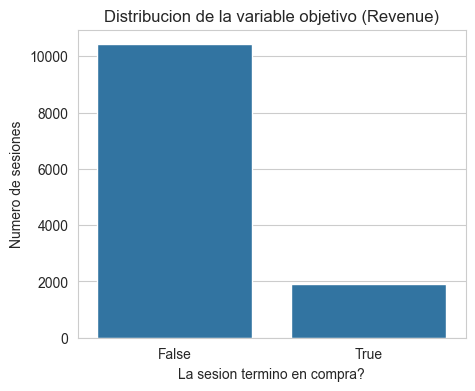

In [6]:
conteo = df["Revenue"].value_counts()
print("Numero de sesiones por clase:")
print(conteo)

porcentaje = df["Revenue"].value_counts(normalize=True) * 100
print("\nPorcentaje por clase:")
print(porcentaje.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Revenue")
plt.title("Distribucion de la variable objetivo (Revenue)")
plt.xlabel("La sesion termino en compra?")
plt.ylabel("Numero de sesiones")
plt.show()


**Interpretacion:** Las clases estan muy **desbalanceadas**: de las 12.330 sesiones, solo **1.908 (15.47%)** terminaron en compra, frente a **10.422 (84.53%)** que no. Es decir, aproximadamente **1 de cada 6 sesiones** convierte.

Esto confirma el reto anticipado: un modelo que simplemente prediga "no compra" para todas las sesiones acertaria el ~84.5% de las veces, pero seria inutil porque nunca detectaria una compra real. Por eso en la Seccion 2 **no se usara solo la exactitud (accuracy)** como metrica, sino tambien **precision, recall y F1**, que si miden que tan bien se detecta la clase minoritaria (las compras).

### 1.7 Limpieza minima: valores nulos y duplicados

Antes de modelar se revisan dos cosas basicas: si faltan datos (valores nulos) y si hay filas repetidas (duplicados).

In [7]:
print("Valores nulos por columna:")
print(df.isnull().sum())

duplicados = df.duplicated().sum()
print("\nNumero de filas duplicadas:", duplicados)


Valores nulos por columna:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Numero de filas duplicadas: 125


**Interpretacion:** No hay valores nulos en ninguna columna, asi que no es necesario rellenar datos. Si se encontraron **125 filas completamente duplicadas** (~1% de los datos).

Se decide **eliminarlas**, por dos razones: (1) es la practica estandar al limpiar datos, y (2) evita la **fuga de datos** (*data leakage*) que ocurriria si una copia de una fila duplicada quedara en el conjunto de entrenamiento y otra en el de prueba en la Seccion 2, lo que inflaria artificialmente el rendimiento del modelo.

In [8]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dimensiones despues de eliminar duplicados:", df.shape)
print("Duplicados restantes:", df.duplicated().sum())


Dimensiones despues de eliminar duplicados: (12205, 18)
Duplicados restantes: 0


### 1.8 Resumen de la Seccion 1

| Aspecto | Hallazgo |
|---|---|
| Tamaño final | 12.205 sesiones (tras eliminar 125 duplicados) y 18 variables |
| Valores nulos | Ninguno |
| Variable objetivo | `Revenue` (compra / no compra) |
| Balance de clases | **Desbalanceado**: ~15.5% compra, ~84.5% no compra |
| Tipos de variables | Mezcla de numericas, categoricas (`Month`, `VisitorType`) y booleanas |
| Escalas | Muy distintas entre variables numericas |
| Codigos categoricos | `OperatingSystems`, `Browser`, `Region`, `TrafficType` son numeros pero representan categorias |

**Que implica esto para la Seccion 2 (Modelado):**

- Como las clases estan **desbalanceadas**, los modelos se evaluaran con **precision, recall y F1**, no solo con accuracy.
- Como las **escalas** son muy distintas, las variables numericas se **escalaran**.
- Como hay variables **categoricas** (incluidas las que estan "disfrazadas de numero"), se **codificaran** para que los modelos las entiendan.
- Todos estos pasos de preparacion se organizaran en un **Pipeline** de Scikit-learn, que los aplica de forma ordenada y reproducible.

Con los datos ya entendidos y limpios, en la Seccion 2 se entrenaran y compararan dos modelos: **Regresion Logistica** y **Random Forest**.

## Seccion 2 - Modelado / Analisis

En esta seccion se entrenan y comparan dos modelos para predecir `Revenue`: **Regresion Logistica** (modelo simple e interpretable, usado como referencia o *baseline*) y **Random Forest** (modelo mas potente, basado en arboles de decision).

El flujo es: separar las variables del objetivo, dividir los datos en entrenamiento y prueba, preparar las variables con un **Pipeline** (escalar las numericas y codificar las categoricas), entrenar ambos modelos y compararlos con metricas apropiadas para un problema **desbalanceado**.

### 2.1 Separar las variables predictoras (`X`) y el objetivo (`y`)

Se divide el dataset en dos: `X` contiene las 17 variables que describen el comportamiento de la sesion, e `y` contiene la columna `Revenue` que se quiere predecir.

In [9]:
X = df.drop(columns="Revenue")
y = df["Revenue"]

print("X (variables):", X.shape)
print("y (objetivo): ", y.shape)


X (variables): (12205, 17)
y (objetivo):  (12205,)


### 2.2 Division en entrenamiento y prueba (train/test split)

Los datos se dividen en dos grupos: **80% para entrenar** el modelo y **20% para probarlo** con sesiones que nunca vio. Asi se mide que tan bien generaliza a datos nuevos.

Se usa `stratify=y` para que ambos grupos mantengan la misma proporcion de compras (~15%), algo importante en un dataset desbalanceado.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("Entrenamiento:", X_train.shape)
print("Prueba:       ", X_test.shape)

print("\nProporcion de compras (True):")
print("Train:", round(y_train.mean() * 100, 2), "%")
print("Test: ", round(y_test.mean() * 100, 2), "%")


Entrenamiento: (9764, 17)
Prueba:        (2441, 17)

Proporcion de compras (True):
Train: 15.63 %
Test:  15.65 %


### 2.3 Preparar las variables: escalar y codificar (ColumnTransformer)

Antes de entrenar, cada variable se prepara segun su tipo:

- **Numericas** (duraciones, conteos, tasas): se **escalan** con `StandardScaler`, que las lleva a todas a un rango comparable. Asi ninguna pesa mas solo por tener numeros grandes.
- **Categoricas** (`Month`, `VisitorType`, los codigos `OperatingSystems` / `Browser` / `Region` / `TrafficType`, y `Weekend`): se **codifican** con `OneHotEncoder`, que convierte cada categoria en columnas de 0 y 1 que el modelo pueda entender.

El **ColumnTransformer** aplica cada transformacion a su grupo de columnas y las combina en un solo paso ordenado.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

columnas_numericas = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay",
]

columnas_categoricas = [
    "Month", "VisitorType",
    "OperatingSystems", "Browser", "Region", "TrafficType",
    "Weekend",
]

preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas),
    ]
)

print("Columnas numericas:", len(columnas_numericas))
print("Columnas categoricas:", len(columnas_categoricas))


Columnas numericas: 10
Columnas categoricas: 7


### 2.4 Modelo 1: Regresion Logistica (dentro de un Pipeline)

Un **Pipeline** encadena la preparacion de los datos (2.3) y el modelo en un solo objeto. Al entrenar, primero prepara los datos y luego ajusta el modelo, automaticamente y en el orden correcto.

Su ventaja clave: el escalado y la codificacion se **aprenden solo con los datos de entrenamiento** y luego se aplican igual a los de prueba, lo que evita la **fuga de datos**.

Se usa `class_weight="balanced"` para que el modelo preste mas atencion a la clase minoritaria (las compras), dado el desbalance.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_logreg = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

pipeline_logreg.fit(X_train, y_train)
print("Modelo de Regresion Logistica entrenado")


Modelo de Regresion Logistica entrenado


### 2.5 Modelo 2: Random Forest (mismo Pipeline)

Se entrena el segundo modelo con la misma estructura: el **mismo preprocesador**, pero con un **Random Forest** en lugar de la Regresion Logistica. Reutilizar el preprocesador asegura que ambos modelos reciben los datos preparados igual, de modo que la comparacion sea justa.

- `n_estimators=200` → el bosque tendra 200 arboles.
- `class_weight="balanced"` → igual que antes, compensa el desbalance.

In [13]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)),
])

pipeline_rf.fit(X_train, y_train)
print("Modelo de Random Forest entrenado")


Modelo de Random Forest entrenado


### 2.6 Comparacion de los modelos con metricas

Como el dataset esta desbalanceado, no basta con la **exactitud (accuracy)**. Se usan cuatro metricas, calculadas sobre el conjunto de **prueba** y enfocadas en la clase "compra":

| Metrica | Que mide |
|---|---|
| **Accuracy** | % de aciertos sobre todas las sesiones |
| **Precision** | De las sesiones que el modelo predijo como compra, cuantas lo eran de verdad |
| **Recall** | De las compras reales, cuantas logro detectar el modelo |
| **F1** | Equilibrio entre precision y recall |

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_logreg = pipeline_logreg.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

resultados = pd.DataFrame({
    "Regresion Logistica": [
        accuracy_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_logreg),
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
    ],
}, index=["Accuracy", "Precision", "Recall", "F1"])

resultados.round(3)


,Regresion Logistica,Random Forest
Accuracy,0.846,0.897
Precision,0.505,0.751
Recall,0.796,0.513
F1,0.618,0.610


**Interpretacion:** Los dos modelos rinden parecido en general (el **F1 esta casi empatado**: 0.618 vs 0.610), pero se comportan de forma distinta:

- **Random Forest** tiene mejor **accuracy (0.897)** y mejor **precision (0.751)**: cuando predice "compra", acierta el 75% de las veces. Pero su **recall es bajo (0.513)**: solo detecta la mitad de las compras reales.
- **Regresion Logistica** tiene mejor **recall (0.796)**: detecta el 80% de las compras reales, aunque con menor **precision (0.505)**: muchas de sus alertas de "compra" son falsas alarmas.

Hay un **compromiso (trade-off)**: Random Forest es mas cauto y certero pero se le escapan compras; la Regresion Logistica detecta mas compras pero con mas falsas alarmas. Cual conviene depende del objetivo del negocio (se decide en 2.7).

**Metricas independientes del umbral: ROC-AUC y PR-AUC**

Las cuatro metricas anteriores se calculan con el umbral por defecto (0.5): el modelo predice "compra" si estima una probabilidad mayor a 0.5. Para comparar los modelos **sin depender de ese umbral**, se añaden dos metricas que evaluan todas las probabilidades a la vez:

- **ROC-AUC:** mide que tan bien el modelo **separa** las dos clases. Va de 0.5 (azar) a 1.0 (perfecto). Responde: si se toma una compra y una no-compra al azar, ¿con que probabilidad el modelo le da mayor puntaje a la compra?
- **PR-AUC** (area bajo la curva precision-recall): resume el equilibrio precision/recall a lo largo de todos los umbrales. Es especialmente util en datos **desbalanceados** porque se enfoca en la clase minoritaria (las compras). Su referencia minima es la proporcion de compras (~0.156): cuanto mas alto, mejor.

In [15]:
from sklearn.metrics import roc_auc_score, average_precision_score

# predict_proba devuelve la probabilidad de cada clase; [:, 1] toma la de "compra" (True)
proba_logreg = pipeline_logreg.predict_proba(X_test)[:, 1]
proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

metricas_umbral = pd.DataFrame({
    "Regresion Logistica": [
        roc_auc_score(y_test, proba_logreg),
        average_precision_score(y_test, proba_logreg),
    ],
    "Random Forest": [
        roc_auc_score(y_test, proba_rf),
        average_precision_score(y_test, proba_rf),
    ],
}, index=["ROC-AUC", "PR-AUC"])

metricas_umbral.round(3)


,Regresion Logistica,Random Forest
ROC-AUC,0.910,0.924
PR-AUC,0.663,0.731


### 2.7 Comparacion visual de las metricas

El mismo resumen de metricas, pero en un grafico de barras para comparar los dos modelos de un vistazo.

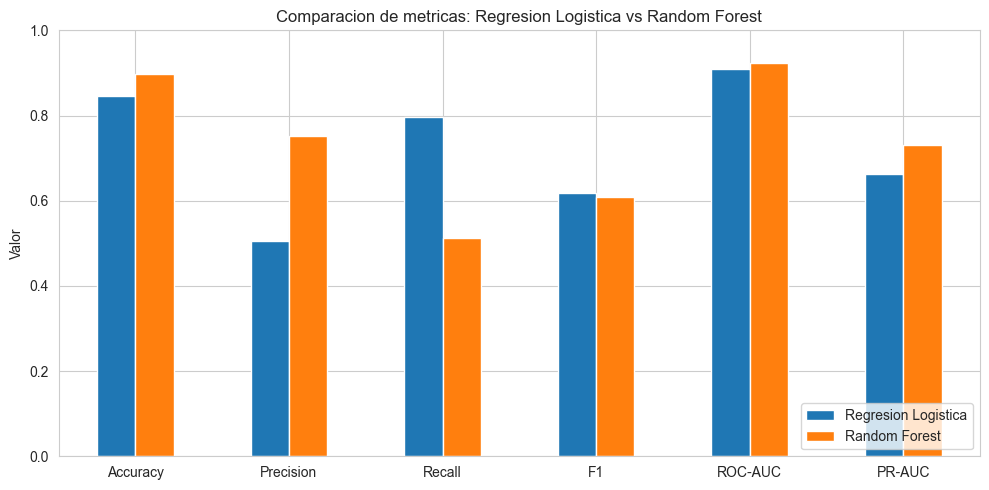

In [16]:
todas_metricas = pd.concat([resultados, metricas_umbral])

ax = todas_metricas.plot.bar(figsize=(10, 5), edgecolor="white")
ax.set_title("Comparacion de metricas: Regresion Logistica vs Random Forest")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretacion:** El grafico confirma el comportamiento de cada modelo: Random Forest domina en accuracy, precision, ROC-AUC y PR-AUC, mientras que la Regresion Logistica solo supera en recall. En F1 quedan practicamente iguales.

### 2.8 Curvas ROC y Precision-Recall

Estas curvas muestran el rendimiento de cada modelo **en todos los umbrales a la vez** (no solo en 0.5). Cuanto mas "arriba" esta una curva, mejor es el modelo.

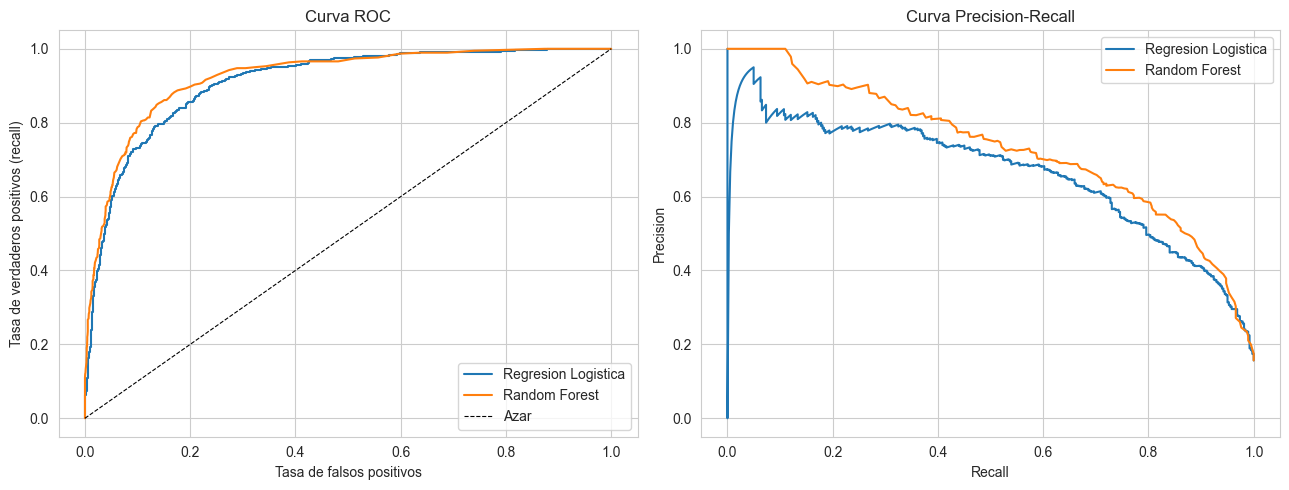

In [17]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curva ROC
for nombre, proba in [("Regresion Logistica", proba_logreg), ("Random Forest", proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=nombre)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Azar")
axes[0].set_title("Curva ROC")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos (recall)")
axes[0].legend()

# Curva Precision-Recall
for nombre, proba in [("Regresion Logistica", proba_logreg), ("Random Forest", proba_rf)]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, label=nombre)
axes[1].set_title("Curva Precision-Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()


**Interpretacion:** En ambas curvas, la de **Random Forest** queda por encima de la de Regresion Logistica, lo que confirma que es el modelo que mejor separa las compras de las no-compras a lo largo de todos los umbrales. La curva Precision-Recall es la mas informativa aqui por el desbalance: muestra que Random Forest mantiene mejor precision al aumentar el recall.

### 2.9 Matrices de confusion

La matriz de confusion muestra, para cada modelo, los aciertos y errores divididos en cuatro casillas: compras bien detectadas, compras perdidas, falsas alarmas y no-compras correctas.

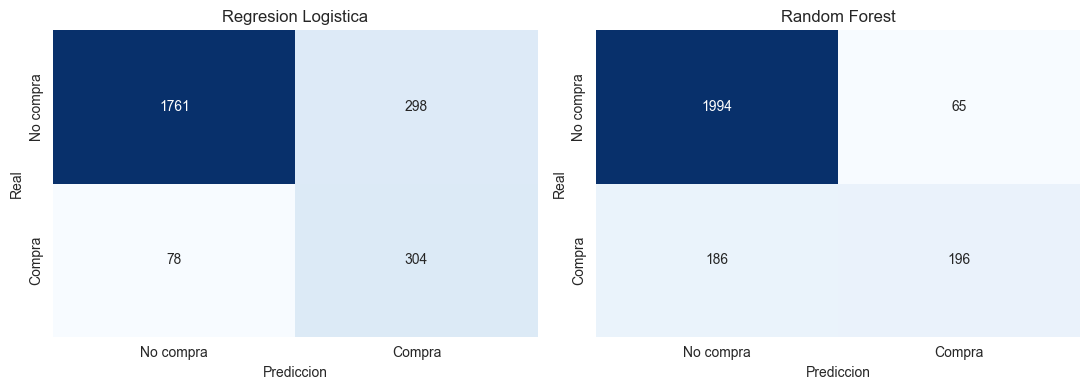

In [18]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, nombre, y_pred in [
    (axes[0], "Regresion Logistica", y_pred_logreg),
    (axes[1], "Random Forest", y_pred_rf),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["No compra", "Compra"],
        yticklabels=["No compra", "Compra"],
    )
    ax.set_title(nombre)
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()


**Interpretacion:** Las matrices hacen visible el trade-off (sobre las 382 compras reales del conjunto de prueba):

- **Regresion Logistica:** detecta **304** compras (recall alto), pero genera **298 falsas alarmas**.
- **Random Forest:** solo **65 falsas alarmas** (mucho mas certero), pero deja escapar mas compras: detecta **196** y pierde **186**.

Esto confirma numericamente lo discutido: Random Forest es mas preciso y cauto; la Regresion Logistica caza mas compras a costa de mas falsas alarmas.

### 2.10 Eleccion del mejor modelo

Resumen de la comparacion sobre el conjunto de prueba:

| Metrica | Regresion Logistica | Random Forest |
|---|---|---|
| Accuracy | 0.846 | **0.897** |
| Precision | 0.505 | **0.751** |
| Recall | **0.796** | 0.513 |
| F1 | **0.618** | 0.610 |
| ROC-AUC | 0.910 | **0.924** |
| PR-AUC | 0.663 | **0.731** |

Los dos modelos tienen un **F1 casi identico** con el umbral por defecto, pero se comportan distinto:

- La **Regresion Logistica** atrapa mas compras (recall 0.80) a costa de muchas falsas alarmas (precision 0.50).
- **Random Forest** es mas certero (precision 0.75, accuracy 0.90) y, sobre todo, **gana en ROC-AUC y PR-AUC**, las metricas que no dependen del umbral. Es el modelo que **mejor ordena** las sesiones segun su probabilidad de compra.

**Se elige Random Forest como mejor modelo**, por su superioridad en ROC-AUC y PR-AUC. A continuacion (2.11) se analiza la sensibilidad de su umbral, lo que ademas mostrara que su unica debilidad (el recall) se corrige facilmente.

### 2.11 Sensibilidad del umbral del mejor modelo (Random Forest)

Ya elegido el Random Forest, se profundiza en su comportamiento. El umbral por defecto (0.5) no es obligatorio: **bajarlo** hace que el modelo prediga "compra" mas facilmente (sube el recall, baja la precision), y **subirlo** hace lo contrario. Aqui se ve como cambian precision, recall y F1 al mover el umbral, y se identifica el que **maximiza el F1**.

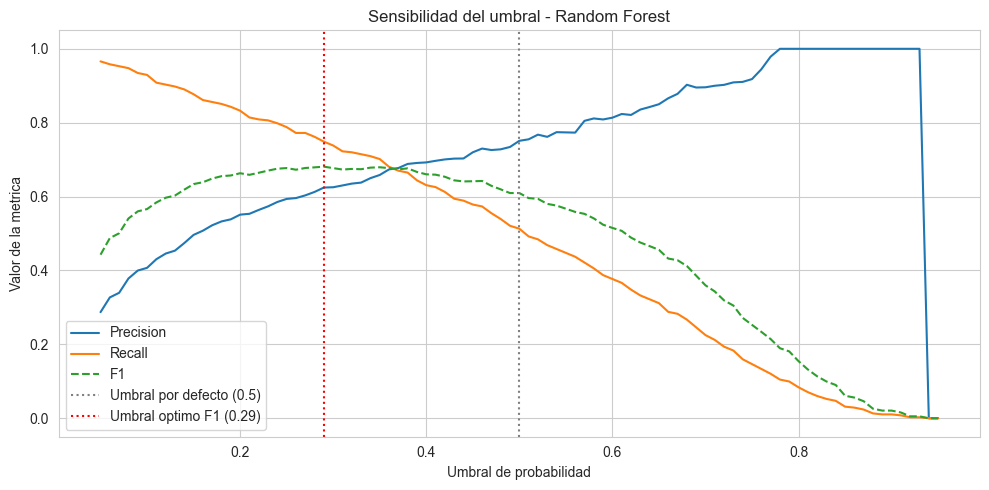

Umbral optimo (max F1): 0.29
  Precision: 0.624
  Recall:    0.749
  F1:        0.681


In [19]:
umbrales = np.arange(0.05, 0.96, 0.01)

precisions = []
recalls = []
f1s = []
for u in umbrales:
    pred_u = proba_rf >= u
    precisions.append(precision_score(y_test, pred_u, zero_division=0))
    recalls.append(recall_score(y_test, pred_u, zero_division=0))
    f1s.append(f1_score(y_test, pred_u, zero_division=0))

# Umbral que maximiza el F1
mejor_idx = int(np.argmax(f1s))
mejor_umbral = umbrales[mejor_idx]

plt.figure(figsize=(10, 5))
plt.plot(umbrales, precisions, label="Precision")
plt.plot(umbrales, recalls, label="Recall")
plt.plot(umbrales, f1s, label="F1", linestyle="--")
plt.axvline(0.5, color="gray", linestyle=":", label="Umbral por defecto (0.5)")
plt.axvline(mejor_umbral, color="red", linestyle=":", label=f"Umbral optimo F1 ({mejor_umbral:.2f})")
plt.title("Sensibilidad del umbral - Random Forest")
plt.xlabel("Umbral de probabilidad")
plt.ylabel("Valor de la metrica")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Umbral optimo (max F1): {mejor_umbral:.2f}")
print(f"  Precision: {precisions[mejor_idx]:.3f}")
print(f"  Recall:    {recalls[mejor_idx]:.3f}")
print(f"  F1:        {f1s[mejor_idx]:.3f}")


**Interpretacion:** El grafico muestra el compromiso clasico: al **bajar** el umbral sube el recall y baja la precision; al **subirlo**, lo contrario. El **umbral optimo segun F1 es 0.29** (no el 0.5 por defecto).

Con ese umbral, el Random Forest pasa de recall 0.51 a **recall 0.75** (atrapa muchas mas compras), con precision 0.62 y un **F1 de 0.681** — mejor que su F1 con umbral 0.5 (0.610) e incluso mejor que el de la Regresion Logistica (0.618).

Esto confirma que el recall bajo del Random Forest **no es un defecto del modelo, sino del umbral**: ajustandolo se consigue buen recall y buena precision a la vez, sin cambiar de modelo.

Con el modelo ya elegido y analizado, en la **Seccion 3** se interpreta con **SHAP** para entender que variables influyen mas en sus predicciones.

## Seccion 3 - Interpretacion

_Pendiente: SHAP aplicado al mejor modelo, minimo 3 visualizaciones con titulo e interpretacion._

## Seccion 4 - Conclusiones

_Pendiente: respuesta a la pregunta, limitaciones del analisis, recomendacion concreta._

## Seccion 5 - Uso de IA

_Pendiente: documentacion de como se usaron herramientas de IA durante el proyecto - que se pidio, que entregaron, que se ajusto._